# Malaria model ranking

Multi-criteria ranking of malaria scam fits. Loads per-task summary CSVs
from a `scam_fits` run, lets you pick which metrics to rank on, runs
Kendall τ on the chosen metrics, then Borda / TOPSIS / Pareto / pairwise
dominance, and surfaces a winners-by-method comparison.

Mirrors `dh_final_diagnostics.ipynb` from idd-tc-mortality.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_forecast_mbp.select.model_selection import (
    CONFIG_COLS,
    DEFAULT_METRICS,
    NO_FE_METRICS,
    CALIBRATION_METRICS,
    prune_redundant_metrics,
    kendall_tau_heatmap,
    borda_rank,
    topsis_rank,
    pareto_frontier,
    pairwise_dominance_summary,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.max_columns = 80
pd.options.display.width = 160

METRICS = {
    'is_r_sq':       'higher',
    'is_mae':        'lower',
    'is_pfpr_mae':   'lower',
    'is_pfpr_r':     'higher',
    'oos_mae':       'lower',
    'oos_r_sq':      'higher',
    'oos_pfpr_mae':  'lower',
    'oos_pfpr_r':    'higher',
    'is_no_fe_r_sq': 'higher',
    'is_no_fe_mae':  'lower',
    'is_no_fe_pfpr_mae':   'lower',
    'is_no_fe_pfpr_r':     'higher',
}

## Paths

Edit `FIT_OUTPUT_DIR` to point at the scam_fits run you want to rank.
Each task writes one `*summary*.csv` in this dir; the load cell
concatenates them.

In [3]:
FIT_OUTPUT_DIR = Path(
    '/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260514_v2'
    # '/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260519'
)

assert FIT_OUTPUT_DIR.exists(), f'Missing: {FIT_OUTPUT_DIR}'
summary_files = sorted(FIT_OUTPUT_DIR.glob('*summary*.csv'))
print(f'Found {len(summary_files)} summary CSVs in {FIT_OUTPUT_DIR}')

Found 1004 summary CSVs in /mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260514_v2


In [4]:
df = pd.concat(
    [pd.read_csv(p) for p in summary_files],
    ignore_index=True,
)
df = df.drop_duplicates('formula_text').reset_index(drop=True)


In [5]:
# For each n_smooth calculate percent that have is_converged true, is_no_fe_convergedm and oos_n_folds_ok == 5
convergence_summary = (
    df.groupby('n_smooths')
    .agg(
        n_models=('formula_text', 'size'),
        pct_converged=('is_converged', 'mean'),
        pct_no_fe_converged=('is_no_fe_converged', 'mean'),
        pct_oos_n_folds_ok_5=('oos_n_folds_ok', lambda x: (x == 5).mean()),
    )
    .reset_index()
)
print(convergence_summary)


   n_smooths  n_models  pct_converged  pct_no_fe_converged  pct_oos_n_folds_ok_5
0          2        72       1.000000             0.875000              1.000000
1          3       253       1.000000             0.778656              1.000000
2          4       253       0.996047             0.739130              1.000000
3          5        91       0.978022             0.758242              0.989011
4          6         5       1.000000             1.000000              1.000000


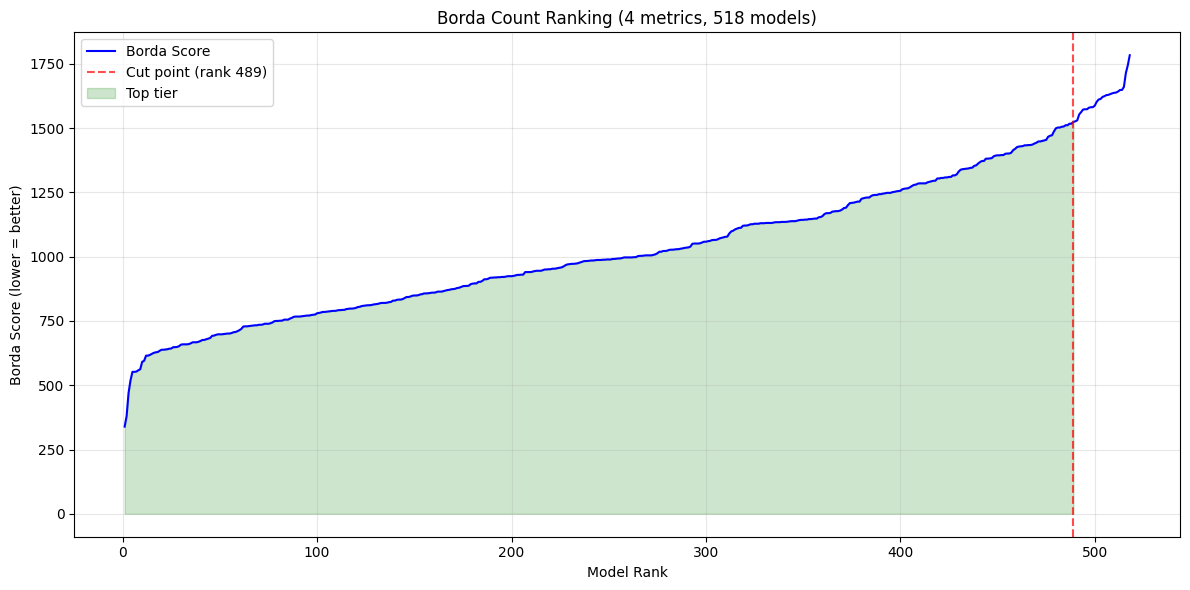


=== Borda Count Summary ===
Total models: 518
Metrics used: 4
Suggested cutpoint: rank 489 (top 489 models)
Top tier Borda range: 339.0 - 1524.0
Bottom tier starts at: 1526.0

=== TOPSIS Ranking (normalize=minmax) ===
Models ranked: 518
Metrics used: 4

Top 10 by TOPSIS:
   topsis_rank  topsis_score   oos_mae  oos_pfpr_mae  is_no_fe_mae  is_no_fe_pfpr_mae
0          1.0      0.811780  4.455419      0.084273      3.933171           0.081344
1          2.0      0.810506  4.451012      0.084052      3.947652           0.081456
2          3.0      0.786426  4.473874      0.084315      3.947752           0.081457
3          4.0      0.751473  4.558075      0.084382      3.917087           0.081390
4          5.0      0.745041  4.428431      0.085129      3.922173           0.081649
5          6.0      0.737811  4.420094      0.085146      3.935929           0.081685
6          7.0      0.737811  4.420094      0.085146      3.935929           0.081685
7          8.0      0.735801  4.559052 

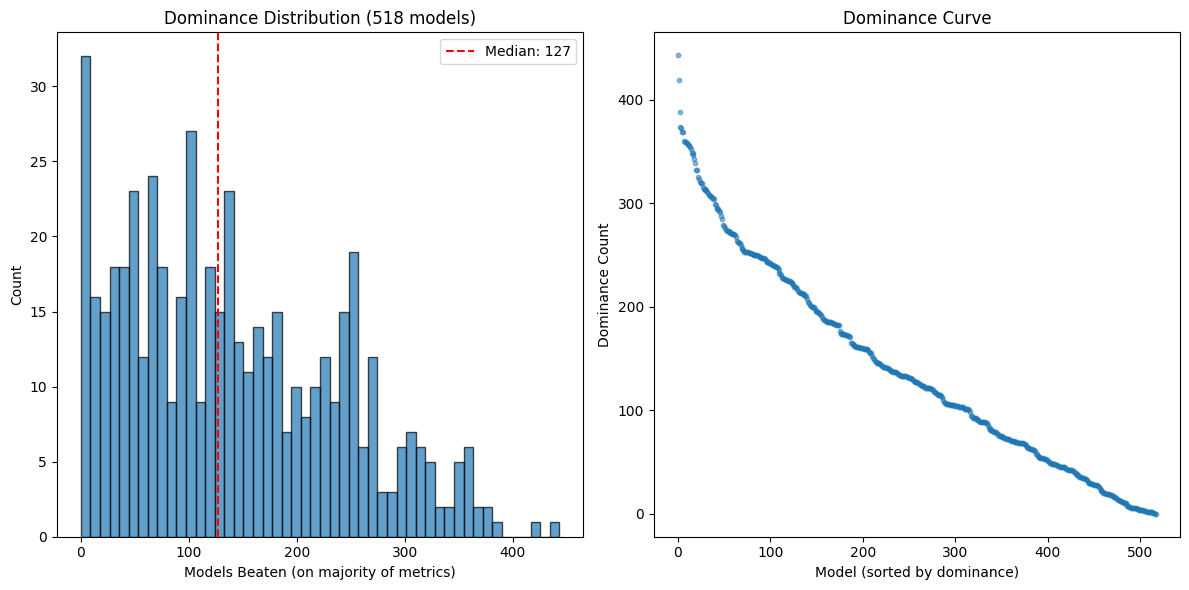


=== Pairwise Dominance Summary ===
Models compared: 518
Metrics used: 4
Max dominance: 443 / 517 models beaten
Median dominance: 127

Top 10 most dominant models:
   dominance_rank  dominance_count  dominance_pct  task_id
0             1.0              443      85.686654       23
1             2.0              419      81.044487      499
2             3.0              388      75.048356        2
3             4.0              374      72.340426      751
4             5.0              373      72.147002      191
5             6.5              369      71.373308       26
6             6.5              369      71.373308       28
7             8.0              360      69.632495        9
8             9.5              359      69.439072        1
9             9.5              359      69.439072        5


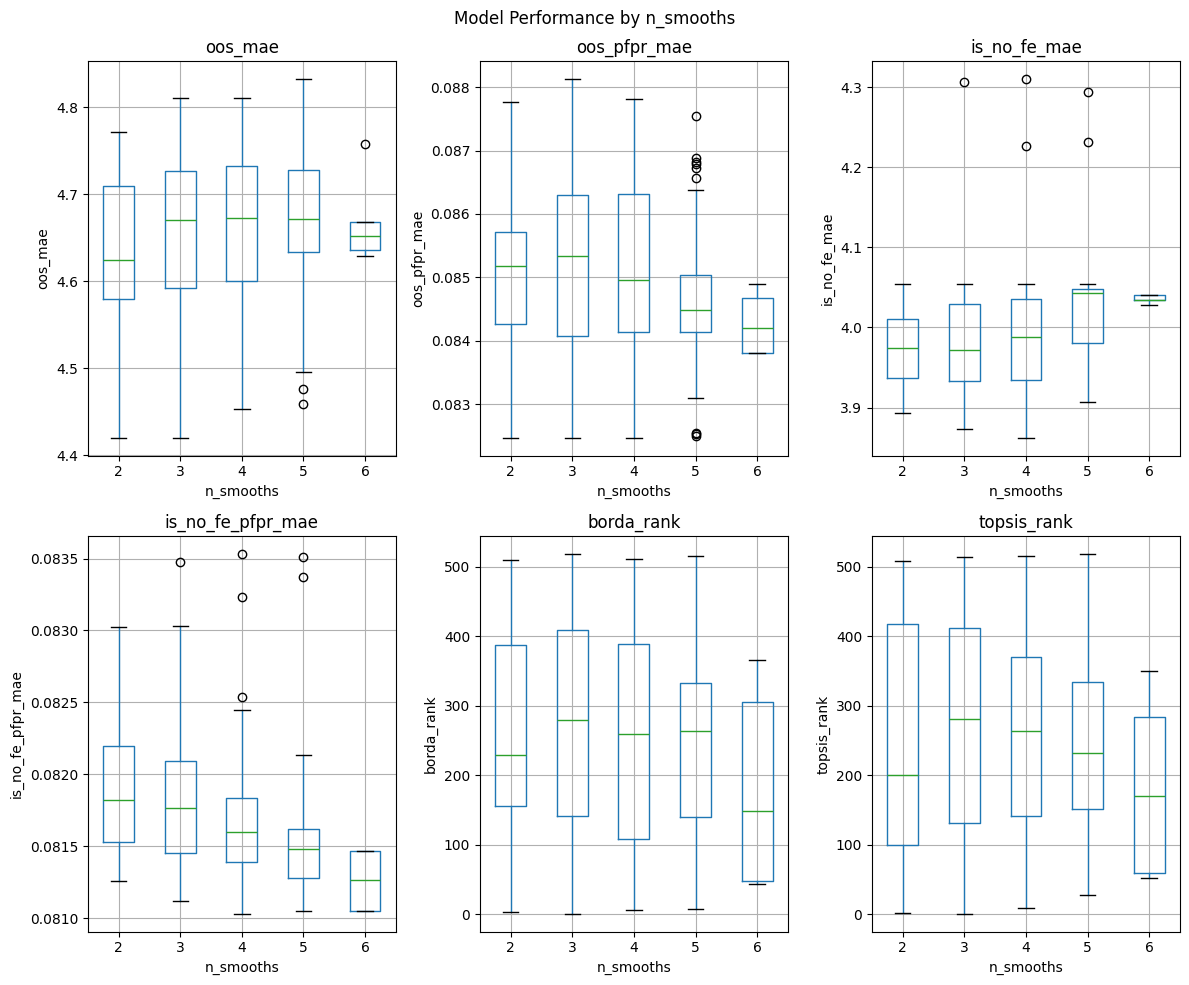

In [7]:
metrics_to_use = {
    'oos_mae':       'lower',
    'oos_pfpr_mae':  'lower',
    'is_no_fe_mae':  'lower',
    'is_no_fe_pfpr_mae':   'lower',
}
df_conv = df.copy()
df_conv = df_conv[(df_conv['is_converged'] == True)]
df_conv = df_conv[(df_conv['is_no_fe_converged'] == True)]
df_conv = df_conv[(df_conv['oos_n_folds_ok'] == 5)]

run_df = df_conv.copy()

metric_df = run_df[CONFIG_COLS + list(DEFAULT_METRICS.keys()) + list(NO_FE_METRICS.keys())]

metrics_present = {k: v for k, v in metrics_to_use.items() if k in metric_df.columns}
calib_present   = [c for c in CALIBRATION_METRICS if c in metric_df.columns]

for metric, direction in metrics_present.items():
    ascending = direction == 'lower'
    run_df[f'{metric}_rank'] = run_df[metric].rank(ascending=ascending, method='min')

borda_df, borda_cutpoint = borda_rank(metric_df, metrics_present, calib_present)
topsis_df, influence = topsis_rank(metric_df, metrics_present, calib_present)
dominance_df = pairwise_dominance_summary(metric_df, metrics_present, calib_present)
best_df = run_df.copy()
best_df = best_df.merge(borda_df[['task_id', 'borda_rank', 'borda_score']], on='task_id', how='left')
best_df = best_df.merge(topsis_df[['task_id', 'topsis_rank', 'topsis_score']], on='task_id', how='left')
best_df = best_df.merge(dominance_df[['task_id', 'dominance_rank', 'dominance_count']], on='task_id', how='left')
best_df = best_df.sort_values('topsis_rank')

panel_metrics = list(metrics_present.keys()) + ['borda_rank', 'topsis_rank']

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
for ax, metric in zip(axes.flatten(), panel_metrics):
    # if metric in ['borda_rank', 'topsis_rank']:
    best_df.boxplot(column=metric, by='n_smooths', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('n_smooths')
    ax.set_ylabel(metric)
plt.suptitle('Model Performance by n_smooths')
plt.tight_layout()
plt.show()

In [8]:
best_df

,task_id,spec_index,formula_text,optimizer,maxit_setting,r_version,scam_version,elapsed_sec,is_elapsed_sec,is_no_fe_elapsed_sec,cv_elapsed_sec,error,error_msg,is_iter,is_converged,is_aic,is_bic,is_loglik,is_deviance,is_null_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,is_n_obs,is_n_coef,is_edf_sum,is_edf_smooth,is_edf_parametric,n_smooths,is_max_sp,is_min_sp,smooth_labels,is_no_fe_formula,is_no_fe_error,is_no_fe_iter,is_no_fe_converged,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_rmse,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,cv_strategy,cv_n_folds,cv_seed,cv_iter_per_fold,cv_converged_per_fold,cv_n_converged,oos_rmse,oos_mae,oos_r_sq,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,oos_n_obs,oos_n_folds_ok,cv_fold_rmse_per_fold,cv_fold_mae_per_fold,cv_fold_pfpr_r_per_fold,cv_fold_pfpr_r_min,cv_fold_pfpr_r_max,cv_fold_pfpr_r_sd,oos_mae_rank,oos_pfpr_mae_rank,is_no_fe_mae_rank,is_no_fe_pfpr_mae_rank,borda_rank,borda_score,topsis_rank,topsis_score,dominance_rank,dominance_count
17,23,23,logit_malaria_pfpr ~ s(mal_DAH_total_per_capit...,bfgs,300,4.2.2,1.2.13,1446.411265,617.060423,168.883539,660.467302,False,NaN,5,True,1.411296e+06,1.412120e+06,-705570.159131,2.312447e+06,1.281862e+07,0.819603,0.819603,2.841288,1.984892,0.082031,0.034680,0.872402,286445,86,77.004088,6.004088,71.0,3,0.035218,0.001978,s(mal_DAH_total_per_capita);s(gdppc_mean);s(pe...,logit_malaria_pfpr ~ s(mal_DAH_total_per_capit...,False,4,True,1.715985e+06,1.716059e+06,0.477122,0.477122,4.837270,3.933171,0.175947,0.081344,0.306014,country_no_fe,5,42,2;5;5;5;4,TRUE;TRUE;TRUE;TRUE;TRUE,5,5.400456,4.455419,0.348280,0.180087,0.084273,0.153100,286445,5,6.3208;4.8049;6.1157;4.5746;4.7911,5.4609;3.7827;5.4983;3.5898;3.8057,0.0707;0.3555;0.2656;0.1629;0.1240,0.070725,0.355472,0.114283,8.0,144.0,109.0,78.0,1.0,339.0,1.0,0.811780,1.0,443
1,2,2,logit_malaria_pfpr ~ s(mal_DAH_total_per_capit...,bfgs,300,4.2.2,1.2.13,808.781095,596.723085,41.266912,170.791099,False,NaN,4,True,1.412020e+06,1.412823e+06,-705934.014983,2.318329e+06,1.281862e+07,0.819144,0.819144,2.844899,1.983183,0.080564,0.033942,0.876752,286445,81,75.002616,4.002616,71.0,2,0.028094,0.001361,s(mal_DAH_total_per_capita);s(gdppc_mean),logit_malaria_pfpr ~ s(mal_DAH_total_per_capit...,False,4,True,1.717743e+06,1.717796e+06,0.473895,0.473895,4.852172,3.947652,0.176135,0.081456,0.310508,country_no_fe,5,42,5;5;5;2;5,TRUE;TRUE;TRUE;TRUE;TRUE,5,5.399197,4.451012,0.348584,0.179905,0.084052,0.161580,286445,5,6.3269;4.8082;6.1477;4.5033;4.7978,5.4643;3.8000;5.5376;3.5147;3.7976,0.0665;0.3432;0.2616;0.2838;0.1213,0.066476,0.343213,0.116384,6.0,122.0,180.0,162.0,3.0,470.0,2.0,0.810506,3.0,388
7,9,9,logit_malaria_pfpr ~ s(mal_DAH_total_per_capit...,bfgs,300,4.2.2,1.2.13,808.351602,573.632373,47.782095,186.937134,False,NaN,4,True,1.412011e+06,1.412825e+06,-705928.727212,2.318243e+06,1.281862e+07,0.819150,0.819150,2.844847,1.983804,0.080659,0.033993,0.876440,286445,82,76.002623,4.002623,72.0,2,0.028087,0.001360,s(mal_DAH_total_per_capita);s(gdppc_mean),logit_malaria_pfpr ~ s(mal_DAH_total_per_capit...,False,5,True,1.717745e+06,1.717808e+06,0.473896,0.473896,4.852168,3.947752,0.176142,0.081457,0.310515,country_no_fe,5,42,5;5;5;2;3,TRUE;TRUE;TRUE;TRUE;TRUE,5,5.421972,4.473874,0.343077,0.180135,0.084315,0.152769,286445,5,6.3677;4.8090;6.1489;4.5449;4.8267,5.5032;3.8006;5.5384;3.5566;3.8275,0.0645;0.3422;0.2606;0.2430;0.1138,0.064465,0.342231,0.113396,12.0,155.0,185.0,167.0,4.0,519.0,3.0,0.786426,8.0,360
358,499,499,logit_malaria_pfpr ~ s(mal_DAH_total_per_capit...,bfgs,300,4.2.2,1.2.13,1603.470704,728.833934,155.206802,719.429969,False,NaN,5,True,1.402904e+06,1.403749e+06,-701372.092586,2.245649e+06,1.281862e+07,0.824813,0.824813,2.799950,1.993945,0.098863,0.041339,0.828034,286445,88,79.002953,6.002953,73.0,3,0.023569,0.000654,s(mal_DAH_total_per_capita);s(gdppc_mean);s(pe...,logit_malaria_pfpr ~ s(mal_DAH_total_per_capit...,False,5,True,1.714439e+06,1.714534e+0

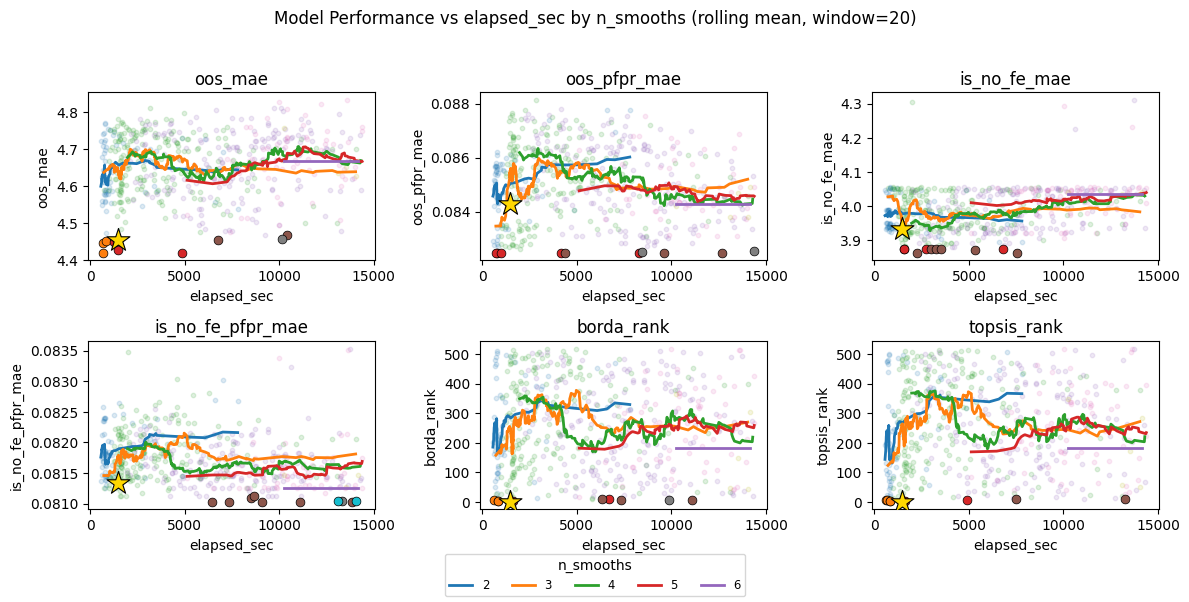

In [13]:

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
winner_idx = best_df[best_df['topsis_rank'] == 1].index
for ax, metric in zip(axes.flatten(), panel_metrics):
    # Identify top 10 (lowest) across all n_smooths for this metric
    top10_idx = best_df.nsmallest(10, metric).index
    for n_smooth, group in best_df.groupby('n_smooths'):
        group_sorted = group.sort_values('elapsed_sec')
        x = group_sorted['elapsed_sec']
        y = group_sorted[metric]
        # Scatter: top-10 points get alpha=1, rest alpha=0.15
        is_top = group_sorted.index.isin(top10_idx)
        ax.scatter(x[~is_top], y[~is_top], alpha=0.15, s=10)
        ax.scatter(x[is_top], y[is_top], alpha=1.0, s=40, zorder=5, edgecolors='black', linewidths=0.5)
        # Rolling mean
        y_smooth = y.rolling(window=20, min_periods=5, center=True).mean()
        ax.plot(x.values, y_smooth.values, label=f'{n_smooth}', linewidth=2)
    # Star for the topsis_rank == 1 winner
    winner = best_df.loc[winner_idx]
    ax.scatter(winner['elapsed_sec'], winner[metric], marker='*', s=300, c='gold',
               edgecolors='black', linewidths=0.8, zorder=10)
    ax.set_title(metric)
    ax.set_xlabel('elapsed_sec')
    ax.set_ylabel(metric)
# Single shared legend below the figure
handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, title='n_smooths', loc='lower center', ncol=len(labels), fontsize='small')
plt.suptitle('Model Performance vs elapsed_sec by n_smooths (rolling mean, window=20)')
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()


In [14]:
df_conv = df.copy()
print(df_conv.shape)
df_conv = df_conv[(df_conv['is_converged'] == True)]
print(df.shape)
df_conv = df_conv[(df_conv['is_no_fe_converged'] == True)]
print(df_conv.shape)
# df_conv = df_conv[(df_conv['cv_n_converged'] == 5)]
# print(df_conv.shape)
df_conv = df_conv[(df_conv['oos_n_folds_ok'] == 5)]
print(df_conv.shape)
df_conv['has_flooding'] = df_conv['formula_text'].str.contains('flood')
df_conv['has_precipitation'] = df_conv['formula_text'].str.contains('precipitation')
df_conv['has_humidity'] = df_conv['formula_text'].str.contains('humidity')
df_conv = df_conv.sort_values('is_no_fe_r_sq', ascending=True)
df_conv[['task_id', 'has_flooding', 'has_precipitation', 'has_humidity', 'is_r_sq', 'is_mae', 'is_pfpr_mae', 'is_pfpr_r', 'oos_mae', 'oos_r_sq', 'oos_pfpr_mae', 'oos_pfpr_r', 'is_no_fe_r_sq', 'is_no_fe_mae', 'is_no_fe_pfpr_mae', 'is_no_fe_pfpr_r']].head(10)


# Best model based on 
# is_no_fe_r_sq: 445 - fine
# is_no_fe_pfpr_r: 22 - 
# is_no_fe_pfpr_mae: 246 - 
# is_no_fe_mae: 445 - 

# oos_r_sq: 4 - missing
# oos_mae: 4 - fine
# oos_pfpr_mae: 1 - missing
# oos_pfpr_r: 1008 - 

# is_mae: 1294 - missing
# is_pfpr_mae: 2 - missing
# oos_pfpr_r: 1 - missing
# is_pfpr_r: 1 - missing
# is_r_sq: 711 - wrong direction


(674, 69)
(674, 69)
(519, 69)
(518, 69)


,task_id,has_flooding,has_precipitation,has_humidity,is_r_sq,is_mae,is_pfpr_mae,is_pfpr_r,oos_mae,oos_r_sq,oos_pfpr_mae,oos_pfpr_r,is_no_fe_r_sq,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r
181,131,True,True,False,0.826756,1.963534,0.037370,0.850475,4.730999,0.254246,0.084100,0.159157,0.383270,4.310902,0.083528,0.376432
20,22,True,False,False,0.819602,1.984860,0.034678,0.872409,4.657310,0.284854,0.082621,0.228438,0.384671,4.306337,0.083476,0.389228
328,273,True,True,False,0.821227,2.004246,0.039489,0.835950,4.826824,0.231545,0.084404,0.129163,0.385638,4.293561,0.083373,0.390761
400,441,True,True,True,0.829233,1.972157,0.041407,0.825906,4.719021,0.253270,0.084929,0.098305,0.398404,4.231484,0.083510,0.107431
415,458,True,True,True,0.829303,1.972459,0.041402,0.826868,4.731387,0.247415,0.084652,0.109786,0.399903,4.226918,0.083231,0.212817
496,565,False,False,True,0.828951,1.979043,0.043264,0.805807,4.590444,0.295396,0.082468,0.255121,0.439634,4.052888,0.081258,0.387681
586,785,False,True,True,0.828965,1.978953,0.043277,0.805603,4.622662,0.286276,0.083742,0.178556,0.439634,4.052888,0.081258,0.387681
262,171,False,True,False,0.829044,1.967898,0.040327,0.832870,4.700594,0.261393,0.084030,0.161930,0.439634,4.052888,0.081258,0.387681
208,1347,False,True,True,0.829262,1.974709,0.042530,0.811751,4.632292,0.290622,0.083463,0.200973,0.439634,4.052888,0.081258,0.387681
498,567,False,False,True,0.828951,1.979044,0.043264,0.805805,4.590444,0.295396,0.082468,0.255121,0.439634,4.052888,0.081258,0.387681


Kendall τ on 518 tasks × 4 metrics

=== Metric Agreement Analysis ===
Average pairwise Kendall tau: -0.029
Pairs with negative correlation: 3
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).


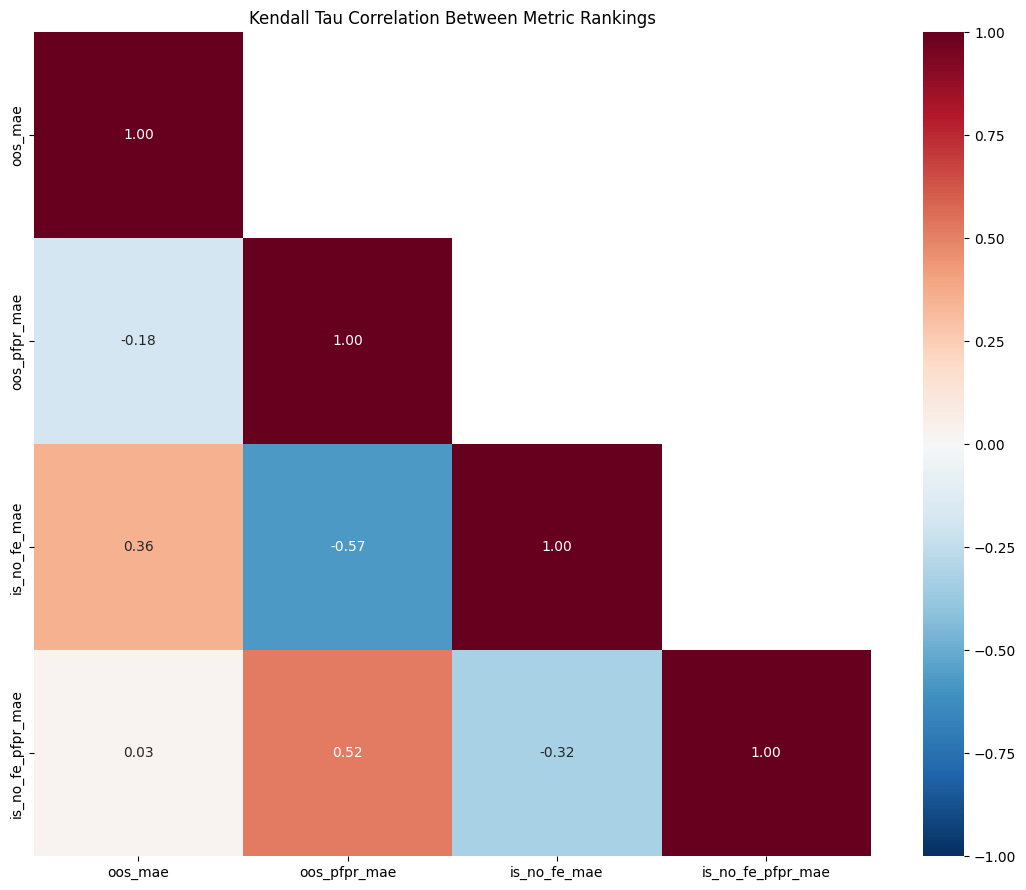


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: -0.029
Pairs with negative correlation: 3
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).

=== Pairwise Dominance Summary ===
Models compared: 518
Metrics used: 4
Max dominance: 443 / 517 models beaten
Median dominance: 127

Top 10 most dominant models:
   dominance_rank  dominance_count  dominance_pct  task_id
0             1.0              443      85.686654       23
1             2.0              419      81.044487      499
2             3.0              388      75.048356        2
3             4.0              374      72.340426      751
4             5.0              373      72.147002      191
5             6.5              369      71.373308       26
6             6.5              369      71.373308       28
7             8.0              360      69.632495        9
8             9.5              359      69.439072        1
9             9.5              359      69.439072        5


,task_id,borda_rank,borda_score,topsis_rank,topsis_score,dominance_rank,dominance_count,has_flooding,has_precipitation,has_humidity,oos_mae_rank,oos_pfpr_mae_rank,is_no_fe_mae_rank,is_no_fe_pfpr_mae_rank
412,23,1.0,339.0,1.0,0.811780,1.0,443,True,False,False,8.0,144.0,109.0,78.0
321,2,3.0,470.0,2.0,0.810506,3.0,388,False,False,False,6.0,122.0,180.0,162.0
326,9,4.0,519.0,3.0,0.786426,8.0,360,True,False,False,12.0,155.0,185.0,167.0
472,499,2.0,380.0,4.0,0.751473,2.0,419,True,True,True,68.0,165.0,50.0,97.0
430,25,14.0,618.0,5.0,0.745041,49.0,285,True,False,False,3.0,275.0,80.0,260.0
331,4,50.0,698.0,6.0,0.737811,75.0,253,False,False,False,1.0,277.0,143.0,277.0
329,564,50.0,698.0,7.0,0.737811,75.0,253,False,False,True,2.0,276.0,145.0,275.0
407,478,5.5,552.0,8.0,0.735801,31.5,313,False,True,True,72.0,136.0,107.0,237.0
318,1346,23.0,640.0,9.0,0.733420,23.0,325,False,True,True,16.0,278.0,183.0,163.0
319,786,25.0,643.0,10.0,0.733002,24.0,323,False,True,True,17.0,279.0,182.0,165.0


In [16]:
metrics_to_use = {
    # ---- In-sample (with fixed effects) ----
    # 'is_aic':        'lower',
    # 'is_bic':        'lower',
    # 'is_deviance':   'lower',
    # 'is_dev_expl':   'higher',
    # 'is_r_sq':       'higher',
    # 'is_rmse':       'lower',
    # 'is_mae':        'lower',

    # ---- In-sample PfPR ----
    # 'is_pfpr_rmse':  'lower',
    # 'is_pfpr_mae':   'lower',
    # 'is_pfpr_r':     'higher',

    # ---- Out-of-sample ----
    # 'oos_rmse':      'lower',
    'oos_mae':       'lower',
    # 'oos_r_sq':      'higher',

    # ---- Out-of-sample PfPR ----
    # 'oos_pfpr_rmse': 'lower',
    'oos_pfpr_mae':  'lower',
    # 'oos_pfpr_r':    'higher',

    # ---- No-FE metrics ----
    # 'is_no_fe_aic':  'lower',
    # 'is_no_fe_bic':  'lower',
    # 'is_no_fe_dev_expl': 'higher',
    # 'is_no_fe_r_sq': 'higher',
    # 'is_no_fe_rmse': 'lower',
    'is_no_fe_mae':  'lower',
    'is_no_fe_pfpr_mae':   'lower',
    # 'is_no_fe_pfpr_r':     'higher',
}

run_df = df_conv.copy()


metric_df = run_df[CONFIG_COLS + list(DEFAULT_METRICS.keys()) + list(NO_FE_METRICS.keys())]

metrics_present = {k: v for k, v in metrics_to_use.items() if k in metric_df.columns}
calib_present   = [c for c in CALIBRATION_METRICS if c in metric_df.columns]


missing = [k for k in metrics_to_use if k not in metric_df.columns]
if missing:
    print(f'\n[note] {len(missing)} requested metrics not in metric_df (skipped): {missing}')

print(f'Kendall τ on {len(metric_df):,} tasks × {len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(metric_df, metrics_present, calib_present, plot = False)
metrics_present, prune_log = prune_redundant_metrics(tau_df, metrics_present, threshold=0.7)
tau_df = kendall_tau_heatmap(metric_df, metrics_present, calib_present, figsize=(11, 9))
plt.show()

# For each metric in metrics_present, create column "{metric}_rank" with rank of each model on that metric (1 = best)
for metric, direction in metrics_present.items():
    ascending = direction == 'lower'
    run_df[f'{metric}_rank'] = run_df[metric].rank(ascending=ascending, method='min')

borda_df, borda_cutpoint = borda_rank(metric_df, metrics_present, calib_present, plot = False)
topsis_df, influence = topsis_rank(metric_df, metrics_present, calib_present, verbose=False)
dominance_df = pairwise_dominance_summary(metric_df, metrics_present, calib_present, plot = False)
best_df = run_df.copy()
best_df = best_df.merge(borda_df[['task_id', 'borda_rank', 'borda_score']], on='task_id', how='left')
best_df = best_df.merge(topsis_df[['task_id', 'topsis_rank', 'topsis_score']], on='task_id', how='left')
best_df = best_df.merge(dominance_df[['task_id', 'dominance_rank', 'dominance_count']], on='task_id', how='left')
best_df = best_df.sort_values('topsis_rank')

best_df[['task_id', 'borda_rank', 'borda_score', 'topsis_rank', 'topsis_score', 'dominance_rank', 'dominance_count', 'has_flooding', 'has_precipitation', 'has_humidity'] + [f'{metric}_rank' for metric in metrics_present.keys()]].sort_values('topsis_rank').head(10)

In [17]:
print(df[df['task_id'] == 23]['formula_text'].iloc[0])

logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 6, bs = "mpd") + s(gdppc_mean, k = 6, bs = "mpd") + weighted_1km_urban_threshold_300.0_simple_mean + s(people_flood_days_per_capita, k = 6, bs = "cv") + logit_malaria_suitability + A0_af


In [7]:
df[df['formula_text'].str.contains('suit')][['task_id', 'formula_text']].head(10)

,task_id,formula_text
